In [448]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from ast import literal_eval
from scipy import stats

In [449]:
#df = pd.read_csv('../Outputs/pre_matching_df.csv', converters={'color_identity': literal_eval})
#df = pd.read_csv('../Results/pre_matching_df_T2_58WR.csv', converters={'color_identity': literal_eval})
#df = pd.read_csv('../Results/pre_matching_df_T2_60WR.csv', converters={'color_identity': literal_eval})
#df = pd.read_csv('../Results/pre_matching_df_T2_56WR.csv', converters={'color_identity': literal_eval})
#df = pd.read_csv('../Results/pre_matching_df_T2_62WR.csv', converters={'color_identity': literal_eval})
df = pd.read_csv('../Results/pre_matching_df_T2_54WR.csv', converters={'color_identity': literal_eval})

In [450]:
df[['treatment','control']].value_counts()

treatment  control
False      True       27106
True       False       5916
Name: count, dtype: int64

In [451]:
mean_wins = df['event_match_wins'].mean()

In [ ]:
results_df = df

all_labels = [f"p{pack}p{pick}" for pack in range(1, 4) for pick in range(1, 14)]
results_df['label'] = results_df.apply(lambda r: f"p{int(r.pack)+1}p{int(r.pick)}", axis=1)
results_df_reindexed = results_df.set_index('label').reindex(all_labels)

x = range(len(all_labels))

fig, ax = plt.subplots(figsize=(20, 5))

wins_above_control = results_df_reindexed['treatment_wins'] - results_df_reindexed['control_wins']
ci = np.sqrt(results_df_reindexed['treatment_ci']**2 + results_df_reindexed['control_ci']**2)

ax.bar(x, wins_above_control, width=0.6,
       alpha=0.7, yerr=ci, capsize=3,
       color=np.where(wins_above_control >= 0, '#d55e00', '#0072b2'))

for i, label in enumerate(all_labels):
    if label in results_df.set_index('label').index:
        row = results_df.set_index('label').loc[label]
        if row['sig']:
            plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xticks(x)
plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
ax.set_xticklabels(all_labels, rotation=90)
ax.set_ylabel('Wins Above Control')
ax.set_title('Treatment Effect by Pick (54% Win Rate)')
plt.tight_layout()
plt.legend()
plt.show()

In [452]:

basic_df = df.copy()

basic_df['total_pick'] = basic_df.apply(lambda x: (x['pack_number'] * 13) + x['pick_number'], axis=1)

basic_treatment_wins = basic_df[basic_df['treatment'] == 1].groupby('total_pick')['event_match_wins'].mean()
basic_control_wins = basic_df[basic_df['control'] == 1].groupby('total_pick')['event_match_wins'].mean()

basic_both = pd.merge(basic_treatment_wins, basic_control_wins, how='inner', on='total_pick')


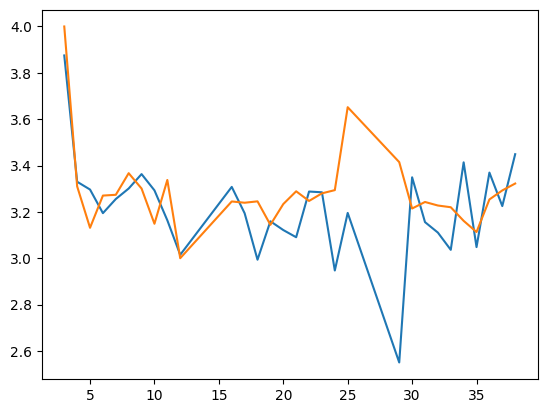

In [453]:
plt.plot(basic_both)
plt.show()

In [454]:
color_list = ['W','U','B','R','G']
color_one_hot_names = ['W_id','U_id','B_id','R_id','G_id']

df['color_identity']

def get_color_identity_match(row):
    color_identity = row['color_identity']

    colors = {x: 1 if x in color_identity else 0 for x in color_list}

    return colors

color_one_hot = df.iloc[1:10].apply(get_color_identity_match, axis=1, result_type='expand')


In [455]:
df[color_one_hot_names] = df.apply(get_color_identity_match, axis=1, result_type='expand')

In [456]:
feature_suffixes = ('_mean','_var',)

feature_cols = [col for col in df.columns if col.endswith(feature_suffixes)]

feature_cols = feature_cols

results_df = pd.DataFrame(columns=['pack','pick','treatment_wins','control_wins','treatment_ci','control_ci','treatment_n','control_n','p_value'])
print(results_df)

for pack in [0,1,2]:
    for pick in range(1,14):
        treatment_df = df.query('pack_number == @pack and pick_number == @pick and treatment')
        control_df = df.query('pack_number == @pack and pick_number == @pick and control')

        if treatment_df.empty or control_df.empty:
            continue
        treatment_draft_ids = list(set(treatment_df['draft_id']))
        control_draft_ids = list(set(control_df['draft_id']))


        scaler = StandardScaler()
        treatment_df = df[df['draft_id'].isin(treatment_draft_ids)]

        #this part seems to be a problem, it gives artifically low values for picks without data
        treatment_df_no_na = treatment_df.fillna(12)
        control_df_no_na = control_df.fillna(12)


        #reduce the dfs down to treatment, instrument, and feature columns, then group by draft ID and take the mean of features
        #treatment_df_grouped = treatment_df_no_na.groupby('draft_id').mean()
        #control_df_grouped = control_df_no_na.groupby('draft_id').mean()

        treatment_df_grouped = treatment_df_no_na[['draft_id'] + feature_cols + color_one_hot_names +  ['event_match_wins', 'event_match_losses']].groupby('draft_id').mean()
        control_df_grouped = control_df_no_na[['draft_id'] + feature_cols + color_one_hot_names + ['event_match_wins', 'event_match_losses']].groupby('draft_id').mean()

        cols = [col for col in df.columns if col.endswith('_mean')]

        #group by draft id, then get ALSA columns, then take the variance, return as a dataframe
        var_cols = df.groupby('draft_id')[cols].var()
        var_cols = var_cols.add_suffix('_var')

        #join variance columns on draft ID to treatment and control
        treatment_df_grouped_var = pd.merge(treatment_df_grouped, var_cols, on='draft_id')
        control_df_grouped_var = pd.merge(control_df_grouped, var_cols, on='draft_id')

        treatment_df_grouped_var.fillna(0,inplace=True)
        control_df_grouped_var.fillna(0,inplace=True)

        #print(control_df_grouped_var.columns)

        #scale control and treatment
        control_scaled = scaler.fit_transform(control_df_grouped_var[feature_cols])
        treatment_scaled = scaler.transform(treatment_df_grouped_var[feature_cols])

        #find nearest neighbor of treatment row
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(control_scaled)
        distances, indices = nn.kneighbors(treatment_scaled, n_neighbors=1)

        matched_indices = indices.flatten()
        matched_control = control_df_grouped_var.iloc[matched_indices].copy()

        treatment_df_grouped_var['treatment'] = 1

        matched_control['treatment'] = 0

        #print(treatment_df_grouped_var.shape, matched_control.shape)

        treatment_group_wins = matched_df[matched_df['treatment'] == 1]['event_match_wins']
        control_group_wins = matched_df[matched_df['treatment'] == 0]['event_match_wins']

        matched_df = pd.concat([treatment_df_grouped_var, matched_control])
        treatment_wins = treatment_group_wins.mean()
        control_wins = control_group_wins.mean()

        treatment_ci = 1.96 * (treatment_group_wins.std() / np.sqrt(len(treatment_group_wins)))
        control_ci = 1.96 * (control_group_wins.std() / np.sqrt(len(control_group_wins)))

        treatment_n = len(treatment_group_wins)
        control_n = len(control_group_wins)
        
        t_stat, p_value = stats.ttest_ind(treatment_group_wins, control_group_wins)
        #print(f'p-value: {p_value}')
        #print(f'p{pack+1}p{pick}: treatment mean wins: {matched_df[matched_df['treatment'] == 1]['event_match_wins'].mean()}')
        #print(f'p{pack+1}p{pick}: control mean wins: {matched_df[matched_df['treatment'] == 0]['event_match_wins'].mean()}')
        results_df.loc[len(results_df)] = [pack,pick,treatment_wins,control_wins,treatment_ci,control_ci,treatment_n,control_n,p_value]






Empty DataFrame
Columns: [pack, pick, treatment_wins, control_wins, treatment_ci, control_ci, treatment_n, control_n, p_value]
Index: []


In [457]:
results_df['total_pick'] = results_df.apply(lambda x: (x['pack'] * 13) + x['pick'], axis=1)
print(results_df.head())


   pack  pick  treatment_wins  control_wins  treatment_ci  control_ci  \
0   0.0   3.0        3.754601      3.674847      0.352930    0.345763   
1   0.0   4.0        3.875000      3.500000      1.501741    0.641561   
2   0.0   5.0        3.329897      2.422680      0.428678    0.352777   
3   0.0   6.0        3.296296      3.222222      0.243954    0.232528   
4   0.0   7.0        3.194444      3.229167      0.197350    0.205577   

   treatment_n  control_n   p_value  total_pick  
0        163.0      163.0  0.751913         3.0  
1          8.0        8.0  0.659543         4.0  
2         97.0       97.0  0.001593         5.0  
3        297.0      297.0  0.666778         6.0  
4        432.0      432.0  0.811306         7.0  


In [458]:
results_df[results_df['p_value'] < .05]
results_df['sig'] = results_df['p_value'].apply((lambda x: True if x <= .05 else False)) 
results_df[results_df['sig'] == True]

,pack,pick,treatment_wins,control_wins,treatment_ci,control_ci,treatment_n,control_n,p_value,total_pick,sig
2,0.0,5.0,3.329897,2.422680,0.428678,0.352777,97.0,97.0,1.592992e-03,5.0,True
5,0.0,8.0,3.255385,2.790769,0.235625,0.193449,325.0,325.0,2.923124e-03,8.0,True
6,0.0,9.0,3.300725,2.840580,0.253139,0.207781,276.0,276.0,6.083869e-03,9.0,True
8,0.0,11.0,3.292818,1.911602,0.310090,0.266999,181.0,181.0,1.340131e-10,11.0,True
9,0.0,12.0,3.163522,2.716981,0.339051,0.278788,159.0,159.0,4.702339e-02,12.0,True
19,1.0,12.0,2.946903,3.482301,0.276143,0.316080,226.0,226.0,1.276657e-02,25.0,True
26,2.0,9.0,3.413636,2.881818,0.283128,0.275647,220.0,220.0,8.639083e-03,35.0,True
27,2.0,10.0,3.048000,2.320000,0.276564,0.230429,250.0,250.0,8.456816e-05,36.0,True
29,2.0,12.0,3.224900,4.040161,0.269027,0.261308,249.0,249.0,2.440231e-05,38.0,True


In [459]:
results_df.to_csv('../Results/post_matching_T2_54WR.csv')

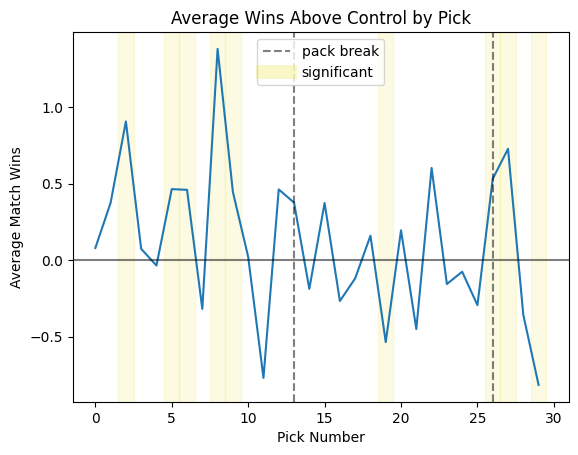

In [460]:
#plt.plot(results_df[['control_wins']])

plt.title('Average Wins Above Control by Pick')
plt.xlabel('Pick Number')
plt.ylabel('Average Match Wins')


plt.plot((results_df['treatment_wins'] - results_df['control_wins']))
for i, row in results_df.iterrows():
    if row['sig']:
        plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')

plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axhline(y=0, color='black', alpha=0.5)
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
plt.plot([], [], color='#f0e442', linewidth=10, label='significant', alpha=0.3)
#plt.errorbar(results_df[['treatment_wins']], treatment_wins, yerr=treatment_ci)
plt.legend()

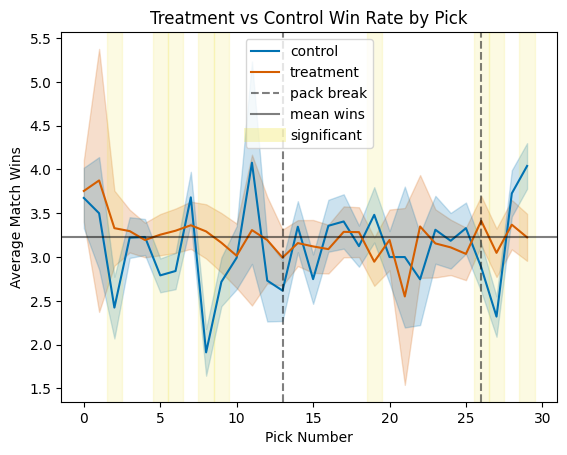

In [461]:
x = range(len(results_df))

plt.title('Treatment vs Control Win Rate by Pick')
plt.xlabel('Pick Number')
plt.ylabel('Average Match Wins')

plt.plot(x, results_df['control_wins'], label='control', color='#0072b2')
plt.plot(x, results_df['treatment_wins'], label='treatment', color='#d55e00')

plt.fill_between(x, 
    results_df['treatment_wins'] - results_df['treatment_ci'],
    results_df['treatment_wins'] + results_df['treatment_ci'],
    alpha=0.2, color='#d55e00')

plt.fill_between(x,
    results_df['control_wins'] - results_df['control_ci'],
    results_df['control_wins'] + results_df['control_ci'],
    alpha=0.2, color='#0072b2')

for i, row in results_df.iterrows():
    if row['sig']:
        plt.axvspan(i - 0.5, i + 0.5, alpha=0.15, color='#f0e442')

plt.axvline(x=13, color='black', linestyle='--', alpha=0.5, label='pack break')
plt.axvline(x=26, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=mean_wins, color='black', alpha=0.5, label = 'mean wins')
plt.plot([], [], color='#f0e442', linewidth=10, label='significant', alpha=0.3)


plt.legend()
plt.show()

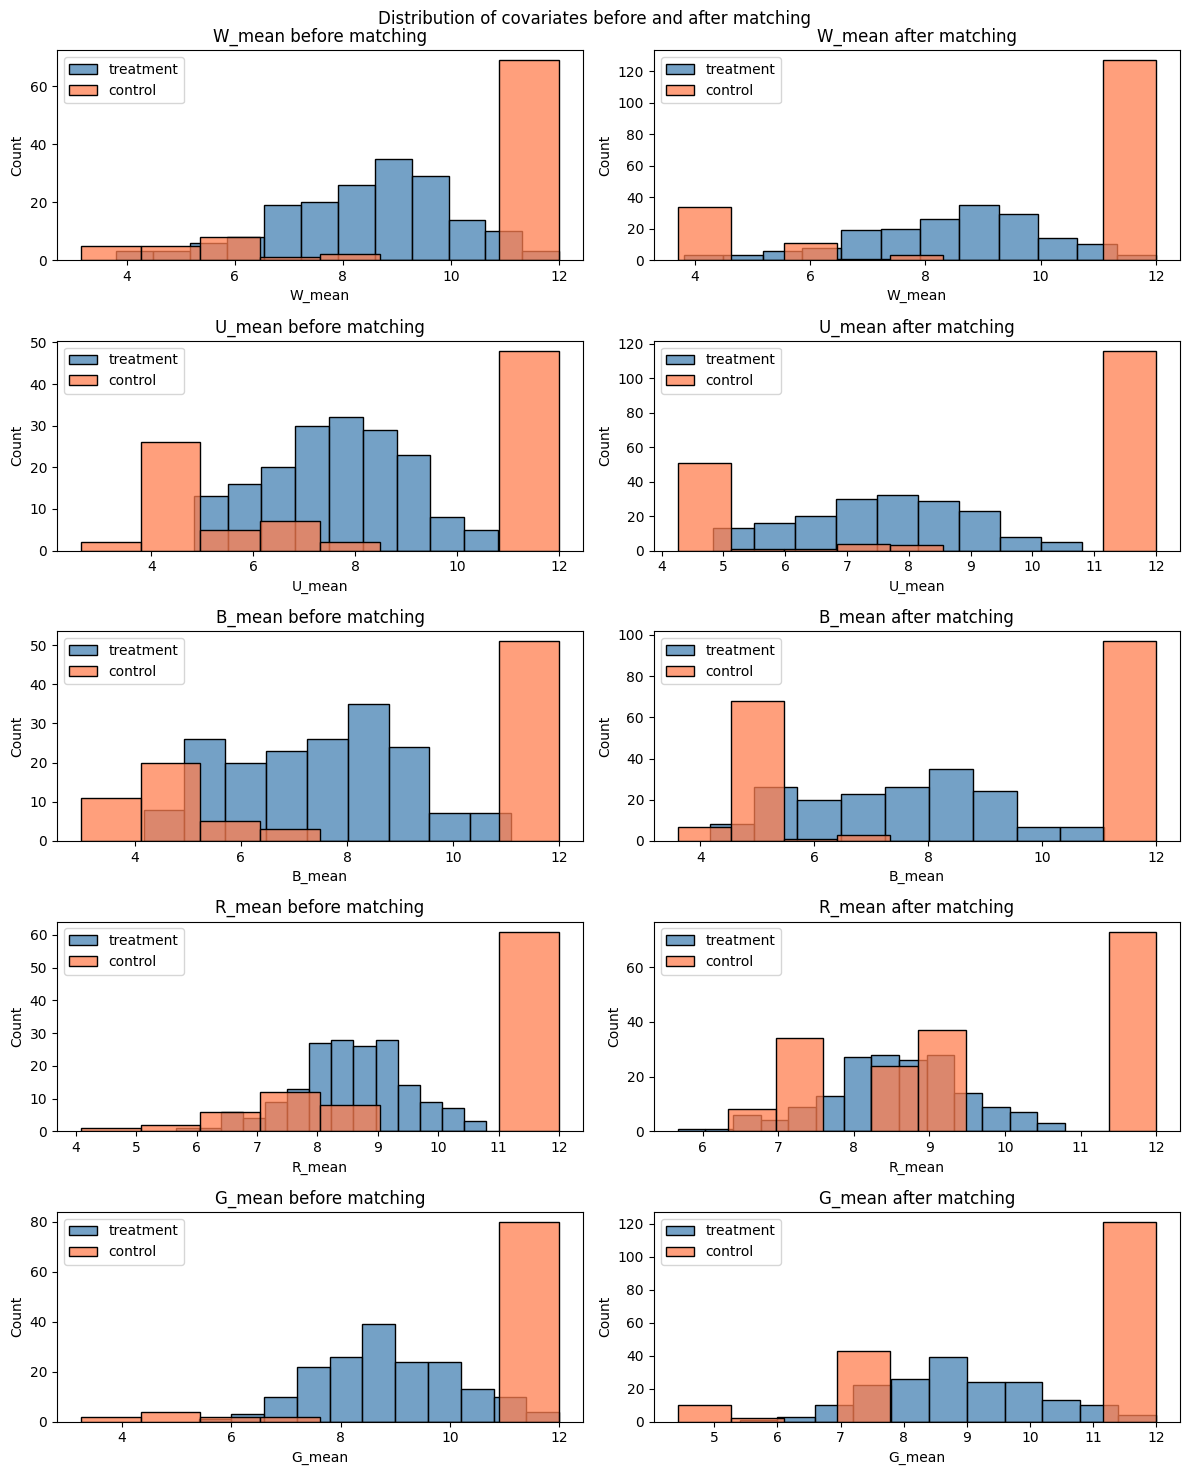

In [462]:
#Plot unbalanced covariates after matching

covariates_mean = ['W_mean','U_mean','B_mean','R_mean','G_mean']
covariates_min = ['W_min','U_min','B_min','R_min','G_min']
covariates_mean_var = ['W_mean_var','U_mean_var','B_mean_var','R_mean_var','G_mean_var']



fig, axs = plt.subplots(5, 2, figsize=(12, 15))
fig.suptitle('Distribution of covariates before and after matching')

for i, item in enumerate(covariates_mean):
    # before matching
    axs[i, 0].set_title(f'{item} before matching')
    sns.histplot(data=treatment_df_grouped_var[item], fill=True, label='treatment', color='steelblue', ax=axs[i, 0])
    sns.histplot(data=control_df_grouped_var[item], fill=True, label='control', color='coral', ax=axs[i, 0])
    axs[i, 0].legend()
   

    
    # after matching
    axs[i, 1].set_title(f'{item} after matching')
    sns.histplot(data=matched_df[matched_df['treatment'] == 1][item], fill=True, label='treatment', color='steelblue', ax=axs[i, 1])
    sns.histplot(data=matched_df[matched_df['treatment'] == 0][item], fill=True, label='control', color='coral', ax=axs[i, 1])
    axs[i, 1].legend()
    

plt.tight_layout()
plt.show()
    